In [3]:
# For conveniance: 
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path
from dotenv import load_dotenv

working_dir = Path.cwd()
while working_dir.name != 'CausalMTR-BC':
    working_dir = working_dir.parent
    if working_dir == Path.home():
        raise FileNotFoundError("Base directory 'CausalMTR-BC' not found")
os.chdir(working_dir)

# Load env variables from config/.env 
dotenv_path = Path("configs/.env")
load_dotenv(dotenv_path=dotenv_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [4]:
from configs.config import Config
import logging
import torch
import numpy as np

In [5]:
config = Config()

In [6]:
from mtr.models import model as model_utils
from cmtr_bc.waymo_iterator import TrajectoryIterator, ProcessedTrajectoryIterator
from torch.utils.data import DataLoader

/scratch/cluster/abitpal/miniconda3/envs/cmtr/lib/python3.11/site-packages/colt5_attention/triton_coor_descent.py:314: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/scratch/cluster/abitpal/miniconda3/envs/cmtr/lib/python3.11/site-packages/colt5_attention/triton_coor_descent.py:410: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


In [7]:
traj_data_loader = ProcessedTrajectoryIterator("/scratch/cluster/abitpal/CausalMTR-BC/data/train/", 500, 2)
traj_data_loader.files = traj_data_loader.files[:1]
train_iterator = DataLoader(traj_data_loader, batch_size=8, collate_fn=TrajectoryIterator.collate_batch)

In [8]:
MODEL_DEVICE = "cuda:0"
model_cfg = config.MODEL
torch.cuda.set_device(0)
model = model_utils.MotionTransformer(config=model_cfg).to(MODEL_DEVICE)

In [9]:
from tqdm import tqdm
from cmtr_bc.batch_dict_visualization import plot_scenario
import matplotlib.pyplot as plt
%matplotlib agg

DEBUG:matplotlib.pyplot:Loaded backend agg version v2.2.


In [10]:
import wandb

In [11]:
wandb.init(project="cmtr-overfitting-test")

NUM_EPOCH = 15
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()
batch_dicts = []
plot_interval = 150
log_interval = 5
num_batches = 0
model.set_epoch(0)
for epoch in range(NUM_EPOCH): 
    last_loss = None
    output_dict = None
    for batch_idx, batch_dict in tqdm(enumerate(train_iterator)): 
        num_batches += 1
        loss, tb_dict, disp_dict, output_dict = model(batch_dict)
        last_loss = loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_value_(model.parameters(), 5.0)
        optimizer.step()
        optimizer.zero_grad()
        wandb.log({"train_loss": loss, "batches": num_batches, "epoch": epoch + 1, "batch_idx": batch_idx})

        if (num_batches % plot_interval == plot_interval - 1): 
            figs = plot_scenario(
                input_dict=output_dict['input_dict'],
                forward_ret_dict=output_dict['forward_ret_dict'],
                num_samples=5,
                plot_object_history=True, 
                plot_object_gt_future=True,
                plot_ego_object_pred_future=True,
            )
            for fig in figs: 
                wandb.log({"plot": wandb.Image(fig)})

    logging.info(f"Epoch: {epoch + 1}, Last loss: {last_loss}")

DEBUG:git.cmd:Popen(['git', 'rev-parse', '--show-toplevel'], cwd=/scratch/cluster/abitpal/CausalMTR-BC, stdin=None, shell=False, universal_newlines=False)
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): api.wandb.ai:443
DEBUG:urllib3.connectionpool:https://api.wandb.ai:443 "POST /graphql HTTP/1.1" 200 None
DEBUG:urllib3.connectionpool:https://api.wandb.ai:443 "POST /graphql HTTP/1.1" 200 None
wandb: Currently logged in as: abitpal (abitpal-the-university-of-texas-at-austin). Use `wandb login --relogin` to force relogin
DEBUG:git.cmd:Popen(['git', 'cat-file', '--batch-check'], cwd=/scratch/cluster/abitpal/CausalMTR-BC, stdin=<valid stream>, shell=False, universal_newlines=False)


0it [00:00, ?it/s]/scratch/cluster/abitpal/CausalMTR-BC/CMTR/mtr/ops/knn/knn_utils.py:70: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  idx = torch.cuda.IntTensor(n, k).zero_()
63it [00:15,  4.08it/s]
INFO:root:Epoch: 1, Last loss: 185.07162475585938
63it [00:14,  4.36it/s]
INFO:root:Epoch: 2, Last loss: 29.047576904296875
22it [00:06,  5.16it/s]DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/scratch/cluster/abitpal/miniconda3/envs/cmtr/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.fo

In [12]:
control_mask = env.cont_agent_mask

obs = env.reset(control_mask)

In [13]:
# Extract full expert trajectory
expert_actions, _, _, _ = env.get_expert_actions()

expert_actions.shape # Shape: (num_envs, num_steps, num_agents, num_actions)

torch.Size([4, 64, 91, 3])

In [14]:
# Reset environment
obs = env.reset(control_mask)
done_envs = []

frames = {f"env_{i}": [] for i in range(NUM_ENVS)}

# Step through the scene
for t in range(env.episode_len):

    env.step_dynamics(expert_actions[:, :, t, :])
    
    dones = env.get_dones()
    
    # Render the scenes
    env_indices = [i for i in range(NUM_ENVS) if i not in done_envs]
    figs = env.vis.plot_simulator_state(
        env_indices=env_indices,
        time_steps=[t]*NUM_ENVS,
        zoom_radius=100,
        #center_agent_indices=[0]*NUM_ENVS,
    )
    for i, env_id in enumerate(env_indices):
        frames[f"env_{env_id}"].append(img_from_fig(figs[i])) 
    
    # Check if done
    for env_id in range(NUM_ENVS):
        if dones[env_id].all():
            done_envs.append(env_id)

env_0
env_1
env_2
env_3

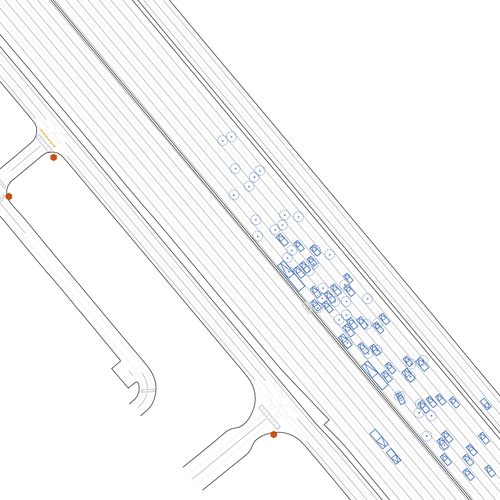
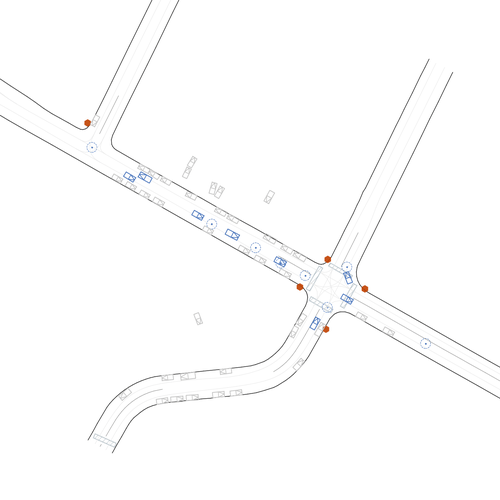
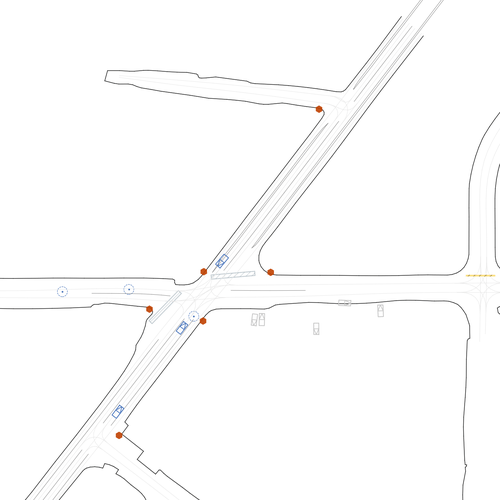
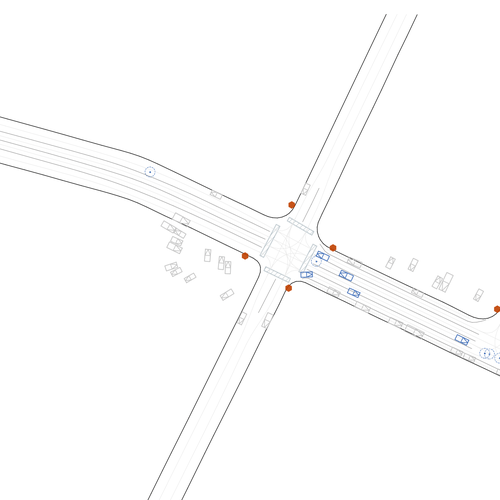

In [70]:
import mediapy
mediapy.show_videos(frames, fps=15, columns=1, codec='gif', width=500)

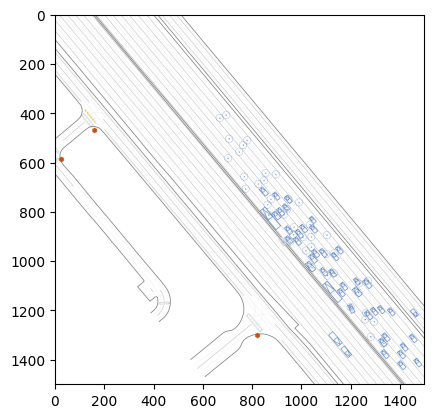

In [25]:
plt.imshow(frames['env_0'][0])

0
1
2
3
4
6
8
9
10
13
14
34
38
39
52
53
55
67
69
70
71
72
73
74
75


(array([1.1000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.0000e+00,
        2.1000e+01, 1.8000e+01, 1.8000e+01, 2.3000e+01, 1.8000e+01,
        5.3000e+01, 2.7900e+02, 3.5700e+02, 5.8500e+02, 4.8800e+02,
        8.1200e+02, 6.4800e+02, 1.9286e+04, 7.7000e+01, 1.3200e+02,
        7.6000e+01, 1.1600e+02, 3.4000e+01, 3.4000e+01, 8.0000e+00,
        1.9000e+01, 2.6000e+01, 3.3000e+01, 3.7000e+01, 2.7000e+01,
        1.4000e+01, 0.0000e+00, 1.2000e+01, 4.0000e+00, 2.0000e+00,
        1.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00, 7.0000e+00,
        3.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.00

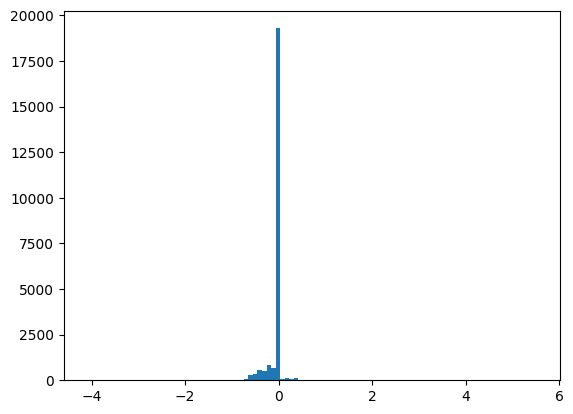

In [71]:
'''
Experimentally clip the difference in positions
'''
from gpudrive.datatypes.observation import (
    LocalEgoState,
    GlobalEgoState,
)

env.reset()
global_ego = GlobalEgoState.from_tensor(
    abs_self_obs_tensor=env.sim.absolute_self_observation_tensor(),
    backend=env.backend,
    device="cpu:1"
)
env_idx = 0
obs_0 = global_ego.pos_x
differences = torch.Tensor([])
obs_0
for i in range(env.episode_len): 
    env.step_dynamics(expert_actions[:, :, i, :])
    global_ego = GlobalEgoState.from_tensor(
        abs_self_obs_tensor=env.sim.absolute_self_observation_tensor(),
        backend=env.backend,
        device="cpu:1"
    )
    obs_1 = global_ego.pos_x
    diff = (obs_1 - obs_0) * (abs(global_ego.pos_x) < 1_000)
    if (abs(diff)).max() > 2:
        print(i)
    differences = torch.concat([differences, diff])
    obs_0 = obs_1

plt.hist(differences.flatten(), bins=100)

In [34]:
obs_1 - obs_0

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

tensor([[[0.0630, 0.1516, 0.1314,  ..., 0.0000, 0.0000, 0.0000],
         [0.0623, 0.1420, 0.1341,  ..., 0.0000, 0.0000, 0.0000],
         [0.0433, 0.1633, 0.1456,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.1550, 0.1354,  ..., 0.0000, 0.0000, 0.0000],
         [0.0232, 0.1515, 0.1469,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.1516, 0.1346,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.1527, 0.1351,  ..., 0.0000, 0.0000, 0.0000],
         [0.0127, 0.1597, 0.1463,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.1605, 0.1422,  ..., 0.0000, 0.0000, 0.